####Goal:

To extract and clean the airline_flights dataset for ELT process source : https://github.com/cgre23/etl-dataset/blob/main/airline_flights.csv

###Environment Setup

In [29]:
import numpy as np
import pandas as pd
import warnings
from datetime import date , timedelta
import re
import os

#for visualiztion
import matplotlib.pyplot as plt
import seaborn as sns

#Configs
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows' , 100)
sns.set_style('darkgrid')

print("All Loaded sucssesfully!")

All Loaded sucssesfully!


###Extract Data

In [30]:
def extract_csv(file_path , encoding='utf-8'):
  """
  Reuseable Csv extraction function with error handling

  parameters:
  -----------
  file_path: str
    The path to the csv file
  encoding: str
      File encoding (default: 'utf-8')

  Returns:
  -------
  pd.Dataframe or None
  """

  try:
    df = pd.read_csv(file_path ,encoding=encoding)
    print("File extracted sucessfully!")
    print(f"Shape : {df.shape}")
    return df
  except FileNotFoundError:
    print(f"Error: File not found {file_path}")
    return None
  except Exception as e:
    print(f"Error Extracting {file_path }: {str(e)}")
    return None

print("=" * 60)
print("EXTRACTING DATA FROM CSV FILES")
print("=" * 60)

airline_flights_raw = extract_csv('airline_flights.csv')

print("\n" + "=" * 60)
print("EXTRACTION COMPLETE")
print("=" * 60)


EXTRACTING DATA FROM CSV FILES
File extracted sucessfully!
Shape : (4000, 15)

EXTRACTION COMPLETE


#### Initial Data profiling

In [31]:
def profile_data(df , name):
  """
  Genarate a quick profile report for a dataframe
  """

  print(f"\n{'=' * 60}")
  print(f"Profile Report for {name}")
  print('=' * 60)
  print(f"\nShape : {df.shape[0]:,} rows x {df.shape[1]} columns")
  print(f"\nColumns and datatypes:")
  print(df.dtypes)
  print(f"\nMemory Usage: {df.memory_usage(deep = True).sum() / 1023:.2f} KB")
  print(f"\nFirst 3 rows:")
  print(df.head(3))
  print(f"\nBasic Statistics:")
  print(df.describe(include='all'))

profile_data(airline_flights_raw , 'airline_flights_raw')



Profile Report for airline_flights_raw

Shape : 4,000 rows x 15 columns

Columns and datatypes:
Date                            object
Departure Time                  object
Revenue ($)                    float64
Passengers (First Class)       float64
Passengers (Business Class)    float64
Passengers (Economy Class)     float64
Origin                          object
Destination                     object
Pod                             object
Distance (km)                  float64
Flight Number                  float64
Aircraft Type                   object
Departure Gate                  object
Arrival Gate                    object
Airline                         object
dtype: object

Memory Usage: 2018.94 KB

First 3 rows:
         Date Departure Time  Revenue ($)  Passengers (First Class)  \
0  2023-06-19          01:37       2393.0                       1.0   
1  2023-06-27          04:10       2236.0                       9.0   
2  2023-06-08          07:44       2072.0         

####Data validation

In [32]:
def validate_extract(df, expected_columns, min_rows=1, name="Dataset"):
    """
    Validate extracted data against business rules
    """

    report = {
        'dataset': name,
        'passed': True,
        'issues': []
    }

    # check if Dataframe is none
    if df is None:
        report['passed'] = False
        report['issues'].append("Dataframe is None")
        return report

    # check row count
    if len(df) < min_rows:
        report['passed'] = False
        report['issues'].append(f"Insufficient rows: {len(df)} < {min_rows}")

    # check missing columns
    missing_cols = set(expected_columns) - set(df.columns)
    if missing_cols:
        report['passed'] = False
        report['issues'].append(f"Missing columns: {missing_cols}")

    # check extra columns
    extra_cols = set(df.columns) - set(expected_columns)
    if extra_cols:
        report['issues'].append(f"Extra columns Found: {extra_cols}")

    # calculate null percentages
    null_pcts = (df.isnull().sum() / len(df) * 100).round(2)
    high_null_cols = null_pcts[null_pcts > 10].to_dict()

    if high_null_cols:
        report['issues'].append(f"High null % : {high_null_cols}")

    # report details
    report['row_count'] = len(df)
    report['column_count'] = len(df.columns)
    report['null_summary'] = null_pcts.to_dict()

    return report


# validating dataset
print("\n" + "="*60)
print("VALIDATION REPORT")
print("="*60)

airline_validation = validate_extract(
    airline_flights_raw,
    ['Date', 'Departure Time', 'Passengers (Economy Class)', 'Revenue ($)', 'Origin', 'Destination'],
    min_rows=100,
    name='airline_flights_raw'
)

# Show report
print(f"\nDataset: {airline_validation['dataset']}")
print(f"Status : {'Passed' if airline_validation['passed'] else 'Failed'}")
print(f"Row Count : {airline_validation.get('row_count')}")
print(f"Column Count : {airline_validation.get('column_count')}")

if airline_validation['issues']:
    print("Issues:")
    for issue in airline_validation['issues']:
        print(f" - {issue}")


VALIDATION REPORT

Dataset: airline_flights_raw
Status : Passed
Row Count : 4000
Column Count : 15
Issues:
 - Extra columns Found: {'Passengers (Business Class)', 'Aircraft Type', 'Pod', 'Airline', 'Departure Gate', 'Passengers (First Class)', 'Distance (km)', 'Flight Number', 'Arrival Gate'}
 - High null % : {'Origin': 14.0, 'Destination': 14.6, 'Departure Gate': 21.12, 'Arrival Gate': 21.4, 'Airline': 18.25}


###Data Cleaning and Processing

In [33]:
def data_quality_report(df , name="Dataset"):
  """
  Comphresive data quality assesment

  Returns a detailed quality report including:
  - Null counts and Percentages
  - Duplicate rows
  - Unique value counts
  - Data type issues
  """

  print(f"\n{'=' * 60}")
  print(f"Data Quality Report : {name}")
  print("=" * 60)

  # Basic Info
  print(f"\nBasic Info:")
  print(f" Total Rows: {len(df):,}")
  print(f" Total Columnnst: {len(df.columns)}")

  #Null analysis
  print(f"\nNull Values: ")
  null_summary = pd.DataFrame({
      'Column' :df.columns,
      'Null_Count': df.isnull().sum().values,
      'Null_Pct' : (df.isnull().sum().values / len(df) * 100).round(2)
  })

  null_summary = null_summary[null_summary['Null_Count'] > 0].sort_values('Null_Pct', ascending=False)
  if len(null_summary) > 0:
        print(null_summary.to_string(index=False))
  else:
      print("No null values found!")

  #Duplicatie Analysis
  print(f"\n Duplicates:")
  total_duplicates = df.duplicated().sum()
  print(f"Total Duplicates: {total_duplicates}")
  if total_duplicates > 0:
    print(f"Percentage of Duplicates: {total_duplicates / len(df) * 100:.2f}%")

  #Unique Values
  print(f"\nUnique Value Counts:")
  unique_summary = pd.DataFrame({
      'Column': df.columns,
      'Unique_Values': [df[col].nunique() for col in df.columns],
      'Unique_Values_Pct': [(df[col].nunique() / len(df)) * 100 for col in df.columns]
  })

  unique_summary['Unique_Values_Pct'] = unique_summary['Unique_Values_Pct'].round(2)
  print(unique_summary.to_string(index=False))

  #data types
  print(f"\nData Types:")
  print(df.dtypes.value_counts())

  return {
      'total_rows': len(df),
      'total_nulls': df.isnull().sum().sum(),
      'total_duplicates': total_duplicates
  }

airline_quality_report = data_quality_report(airline_flights_raw , 'airline_flights_raw')



Data Quality Report : airline_flights_raw

Basic Info:
 Total Rows: 4,000
 Total Columnnst: 15

Null Values: 
                     Column  Null_Count  Null_Pct
               Arrival Gate         856     21.40
             Departure Gate         845     21.12
                    Airline         730     18.25
                Destination         584     14.60
                     Origin         560     14.00
              Distance (km)          23      0.57
Passengers (Business Class)          21      0.52
              Aircraft Type          19      0.48
   Passengers (First Class)          18      0.45
 Passengers (Economy Class)          17      0.43
                Revenue ($)          15      0.38
             Departure Time          13      0.32
              Flight Number          13      0.32
                        Pod          13      0.32

 Duplicates:
Total Duplicates: 0

Unique Value Counts:
                     Column  Unique_Values  Unique_Values_Pct
                     

####Visulizing Data Quality Issues

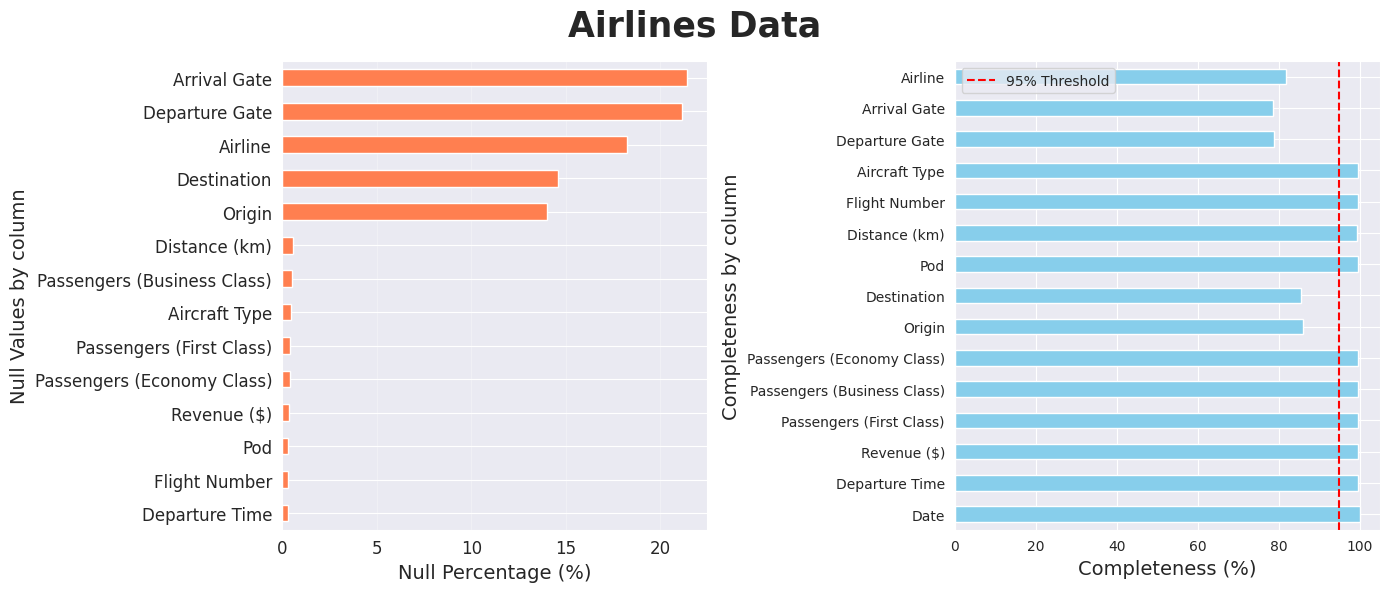

In [34]:
def visualize_data_quality(df , title="Data Quality Overview"):
  """
  Create Visualiztion for data quality issues
  """

  fig, axes = plt.subplots(1 , 2 , figsize=(14 , 6))
  fig.suptitle(title , fontsize=25, fontweight='bold')

  #Null percenatges
  null_pcts = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
  null_pcts[null_pcts > 0].plot(kind='barh' , ax=axes[0] , color='coral')
  axes[0].set_xlabel('Null Percentage (%)', fontsize=14)
  axes[0].set_ylabel('Null Values by column', fontsize=14)
  axes[0].tick_params(axis='both', which='major', labelsize=12)
  axes[0].grid(axis='x' , alpha = 0.3)

  #data Completeness

  completeness = (1 - df.isnull().sum() / len(df)) * 100
  completeness.plot(kind='barh' , ax=axes[1] , color='skyblue')
  axes[1].set_xlabel('Completeness (%)', fontsize=14)
  axes[1].set_ylabel('Completeness by column', fontsize=14)
  axes[1].tick_params(axis='both', which='major', labelsize=12)
  axes[1].axvline(95, color='red', linestyle='--', label='95% Threshold')

  axes[1].tick_params(axis='both', labelsize=10)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

#Visulaise the data

visualize_data_quality(airline_flights_raw, "Airlines Data")

###Handling Null values

In [35]:
import string
#creating backup
airline_flights_raw_backup = airline_flights_raw.copy()

print("=" * 60)
print("\nHandling Null Values")
print("=" * 60)



print(f"\n Before- Nulls : {airline_flights_raw_backup.isnull().sum().sum()}")

#adding plceholders for arrival and departure gate
airline_flights_raw_backup['Arrival Gate'].fillna(
    np.random.choice(list(string.ascii_uppercase)), inplace=True
)

airline_flights_raw_backup['Departure Gate'].fillna(
    np.random.choice(list(string.ascii_uppercase)), inplace=True
)


#Adding mode for Airline
most_common_airline = airline_flights_raw_backup['Airline'].mode()[0]
null_airline_count = airline_flights_raw_backup['Airline'].isnull().sum()
airline_flights_raw_backup['Airline'].fillna(most_common_airline, inplace=True)
print(f"Filled Null Airline Count : {null_airline_count}")

#Adding Mode for Aircraft type
most_common_aircraft_type = airline_flights_raw_backup['Aircraft Type'].mode()[0]
null_aircraft_type_count = airline_flights_raw_backup['Aircraft Type'].isnull().sum()
airline_flights_raw_backup['Aircraft Type'].fillna(most_common_aircraft_type, inplace=True)
print(f"Filled Null Aircraft Type Count : {null_aircraft_type_count}")

#Adding Mode for Origin and destination
most_common_origin = airline_flights_raw_backup['Origin'].mode()[0]
null_origin_count = airline_flights_raw_backup['Origin'].isnull().sum()
airline_flights_raw_backup['Origin'].fillna(most_common_origin, inplace=True)
print(f"Filled Null Origin Count : {null_origin_count}")

most_common_destination = airline_flights_raw_backup['Destination'].mode()[0]
null_destination_count = airline_flights_raw_backup['Destination'].isnull().sum()
airline_flights_raw_backup['Destination'].fillna(most_common_destination, inplace=True)
print(f"Filled Null Destination Count : {null_destination_count}")

#Drop all where null value <5%
rows_before = len(airline_flights_raw_backup)
subset = []
for col in airline_flights_raw_backup.columns:
  if airline_flights_raw_backup[col].isnull().sum() / len(airline_flights_raw_backup) < 0.05:
    subset.append(col)

print(f"Columns considered for dropping rows: {subset}")

airline_flights_raw_backup.dropna(subset=subset , inplace=True)
rows_dropped = rows_before - len(airline_flights_raw_backup)
print(f"Rows before drop : {rows_before}")
print(f"Rows after drop : {len(airline_flights_raw_backup)}")

print("\n" + "="*70)


Handling Null Values

 Before- Nulls : 3727
Filled Null Airline Count : 730
Filled Null Aircraft Type Count : 19
Filled Null Origin Count : 560
Filled Null Destination Count : 584
Columns considered for dropping rows: ['Date', 'Departure Time', 'Revenue ($)', 'Passengers (First Class)', 'Passengers (Business Class)', 'Passengers (Economy Class)', 'Origin', 'Destination', 'Pod', 'Distance (km)', 'Flight Number', 'Aircraft Type', 'Departure Gate', 'Arrival Gate', 'Airline']
Rows before drop : 4000
Rows after drop : 3931



###Revisulizing data for verification after handling null values


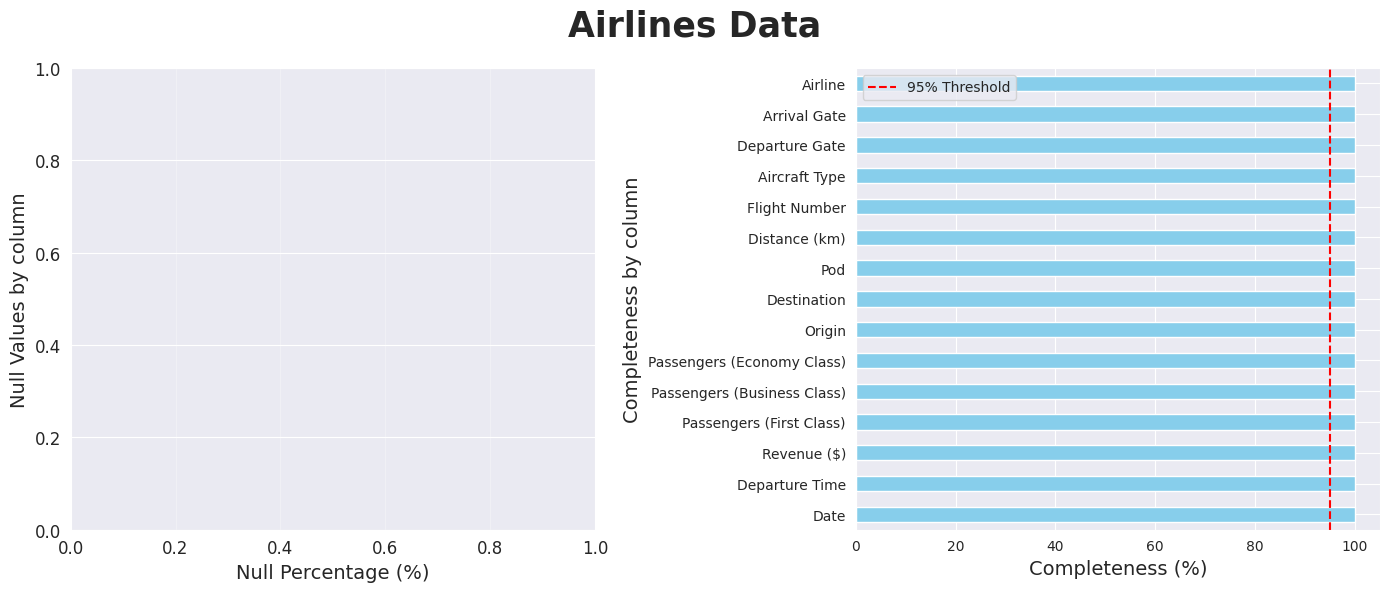

In [36]:
def visualize_data_quality(df , title="Data Quality Overview"):
  """
  Create Visualiztion for data quality issues
  """

  fig, axes = plt.subplots(1 , 2 , figsize=(14 , 6))
  fig.suptitle(title , fontsize=25, fontweight='bold')

  #Null percenatges
  null_pcts = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
  #null_pcts[null_pcts > 0].plot(kind='barh' , ax=axes[0] , color='coral')
  axes[0].set_xlabel('Null Percentage (%)', fontsize=14)
  axes[0].set_ylabel('Null Values by column', fontsize=14)
  axes[0].tick_params(axis='both', which='major', labelsize=12)
  axes[0].grid(axis='x' , alpha = 0.3)

  #data Completeness

  completeness = (1 - df.isnull().sum() / len(df)) * 100
  completeness.plot(kind='barh' , ax=axes[1] , color='skyblue')
  axes[1].set_xlabel('Completeness (%)', fontsize=14)
  axes[1].set_ylabel('Completeness by column', fontsize=14)
  axes[1].tick_params(axis='both', which='major', labelsize=12)
  axes[1].axvline(95, color='red', linestyle='--', label='95% Threshold')

  axes[1].tick_params(axis='both', labelsize=10)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

#Visulaise the data

visualize_data_quality(airline_flights_raw_backup, "Airlines Data")

####Data Type Conversions

In [37]:
print("="*70)
print("DATA TYPE CONVERSIONS")
print("="*70)

print("\nBefore:")
print(airline_flights_raw_backup.dtypes)

#convert Date to datetime
airline_flights_raw_backup['Date'] = pd.to_datetime(airline_flights_raw_backup['Date'], errors='coerce')
print("Converted Date to date time")

#convert Departure Time to datetime
airline_flights_raw_backup['Departure Time'] = pd.to_datetime(airline_flights_raw_backup['Departure Time'], errors='coerce')
print("Converted Departure Time to date time")

#convert Passengers (all classses) to int64
airline_flights_raw_backup['Passengers (Economy Class)'] = pd.to_numeric(airline_flights_raw_backup['Passengers (Economy Class)'], errors='coerce')
airline_flights_raw_backup['Passengers (First Class)'] = pd.to_numeric(airline_flights_raw_backup['Passengers (First Class)'], errors='coerce')
airline_flights_raw_backup['Passengers (Business Class)'] = pd.to_numeric(airline_flights_raw_backup['Passengers (Business Class)'], errors='coerce')

print("\nAfter")
print(airline_flights_raw_backup.dtypes)
print("\n" + "="*70)

DATA TYPE CONVERSIONS

Before:
Date                            object
Departure Time                  object
Revenue ($)                    float64
Passengers (First Class)       float64
Passengers (Business Class)    float64
Passengers (Economy Class)     float64
Origin                          object
Destination                     object
Pod                             object
Distance (km)                  float64
Flight Number                  float64
Aircraft Type                   object
Departure Gate                  object
Arrival Gate                    object
Airline                         object
dtype: object
Converted Date to date time
Converted Departure Time to date time

After
Date                           datetime64[ns]
Departure Time                 datetime64[ns]
Revenue ($)                           float64
Passengers (First Class)              float64
Passengers (Business Class)           float64
Passengers (Economy Class)            float64
Origin               

###Aggregation & Grouping

In [38]:
print("="*70)
print("AGGREGATION & GROUPING EXAMPLES")
print("="*70)

#Highest Earning Airline
print("\nHighest Earning Airline : ")
highest_earning_airline = airline_flights_raw_backup.groupby('Airline')['Revenue ($)'].sum().head(3)
print(highest_earning_airline)

#Popular Destination
print("\nPopular Destination : ")
popular_destination = airline_flights_raw_backup['Destination'].value_counts().head(10)
print(popular_destination)

#Poupular Aircracft Type
print("\nPopular Aircracft Type : ")
popular_aircraft = airline_flights_raw_backup['Aircraft Type'].value_counts().head(5)
print(popular_aircraft)

print("=" * 70)

AGGREGATION & GROUPING EXAMPLES

Highest Earning Airline : 
Airline
American Airlines    4700423.0
British Airways      2468500.0
Emirates             2361969.0
Name: Revenue ($), dtype: float64

Popular Destination : 
Destination
SIN    1142
BOG     567
LAX     567
HND     559
LHR     555
CDG     541
Name: count, dtype: int64

Popular Aircracft Type : 
Aircraft Type
Airbus A380    994
Airbus A320    993
Boeing 737     978
Boeing 777     966
Name: count, dtype: int64


###Save Cleaned Data

In [39]:
os.makedirs('data/cleaned' , exist_ok=True)

airline_flights_raw_backup.to_csv('data/cleaned/airline_flights_cleaned.csv' , index=False)

print("="*70)
print("CLEANED DATA SAVED")
print("="*70)
print(f"Airlines: {len(airline_flights_raw_backup):,}")


CLEANED DATA SAVED
Airlines: 3,931


In [40]:
import pandas as pd
import sqlite3

csv_file_path = "data/cleaned/airline_flights_cleaned.csv"

conn = sqlite3.connect("data/airline_flights.db")
df = pd.read_csv(csv_file_path)
df.to_sql("airline_flights", conn, if_exists="replace", index=False)

cursor = conn.cursor()

print(pd.read_sql_query("SELECT * from airline_flights", conn))


conn.close()


            Date       Departure Time  Revenue ($)  Passengers (First Class)  \
0     2023-06-19  2026-03-08 01:37:00       2393.0                       1.0   
1     2023-06-27  2026-03-08 04:10:00       2236.0                       9.0   
2     2023-06-08  2026-03-08 07:44:00       2072.0                       9.0   
3     2023-07-05  2026-03-08 19:09:00       4286.0                       9.0   
4     2023-06-17  2026-03-08 03:17:00       1748.0                       3.0   
...          ...                  ...          ...                       ...   
3926  2023-06-15  2026-03-08 01:30:00       1311.0                       8.0   
3927  2023-07-05  2026-03-08 07:52:00       4164.0                       8.0   
3928  2023-06-26  2026-03-08 01:50:00       2671.0                       6.0   
3929  2023-06-29  2026-03-08 07:00:00       4009.0                       2.0   
3930  2023-06-14  2026-03-08 01:30:00       2723.0                       5.0   

      Passengers (Business Class)  Pass

##Part-2

In [41]:
# Core libraries
import pandas as pd
import numpy as np
import sqlite3
import logging
import warnings
from datetime import datetime, timedelta
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2


In [42]:
# Load cleaned data from Part 1
print("="*70)
print("LOADING CLEANED DATA FROM PART 1")
print("="*70)

#convert to date time as csv saves in string
airline_clean = pd.read_csv('data/cleaned/airline_flights_cleaned.csv')
airline_clean['Date'] = pd.to_datetime(airline_clean['Date'])
airline_clean['Departure Time'] = pd.to_datetime(airline_clean['Departure Time'])

print("loaded airline datasert")

print("\n" + "="*70)
print("Ready to proceed with transformations!")
print("="*70)

LOADING CLEANED DATA FROM PART 1
loaded airline datasert

Ready to proceed with transformations!


####Convert the table to 3NF/ Normalization to 3NF

In [43]:
import pandas as pd

# ----- AIRLINE TABLE -----
airline = df[['Airline']].drop_duplicates().reset_index(drop=True)
airline['airline_id'] = airline.index + 1

df = df.merge(airline, on='Airline')


# ----- AIRCRAFT TABLE -----
aircraft = df[['Aircraft Type']].drop_duplicates().reset_index(drop=True)
aircraft['aircraft_id'] = aircraft.index + 1

df = df.merge(aircraft, on='Aircraft Type')


# ----- AIRPORT TABLE -----
airports = pd.DataFrame(
    pd.concat([df['Origin'], df['Destination']]).unique(),
    columns=['airport_code']
)

airports['airport_id'] = airports.index + 1

df = df.merge(airports, left_on='Origin', right_on='airport_code')
df.rename(columns={'airport_id':'origin_airport_id'}, inplace=True)
df.drop(columns=['airport_code'], inplace=True)

df = df.merge(airports, left_on='Destination', right_on='airport_code')
df.rename(columns={'airport_id':'destination_airport_id'}, inplace=True)
df.drop(columns=['airport_code'], inplace=True)


# ----- FLIGHT TABLE -----
flight = df[['Flight Number','airline_id','aircraft_id',
             'origin_airport_id','destination_airport_id','Distance (km)']]

flight = flight.drop_duplicates().reset_index(drop=True)


# ----- FLIGHT INSTANCE TABLE -----
flight_instance = df[['Date','Departure Time','Flight Number',
                      'Departure Gate','Arrival Gate','Pod']].copy()

flight_instance['instance_id'] = range(1, len(flight_instance)+1)


# ----- PASSENGER TABLE -----
passengers = df[['Passengers (First Class)',
                 'Passengers (Business Class)',
                 'Passengers (Economy Class)']].copy()

passengers['instance_id'] = flight_instance['instance_id']


# ----- REVENUE TABLE -----
revenue = df[['Revenue ($)']].copy()
revenue['instance_id'] = flight_instance['instance_id']
revenue.rename(columns={'Revenue ($)': 'revenue'}, inplace=True)


# ----- RESULT -----
tables = {
    "Airline": airline,
    "Aircraft": aircraft,
    "Airports": airports,
    "Flights": flight,
    "Flight_Instance": flight_instance,
    "Passengers": passengers,
    "Revenue": revenue
}

for name, table in tables.items():
    print(f"\n{name}")
    print(table.head())


Airline
             Airline  airline_id
0  American Airlines           1
1    British Airways           2
2             Qantas           3
3           Emirates           4

Aircraft
  Aircraft Type  aircraft_id
0    Boeing 737            1
1   Airbus A380            2
2    Boeing 777            3
3   Airbus A320            4

Airports
  airport_code  airport_id
0          LHR           1
1          ORD           2
2          AMS           3
3          JFK           4
4          DXB           5

Flights
   Flight Number  airline_id  aircraft_id  origin_airport_id  \
0          279.0           1            1                  1   
1          605.0           2            1                  2   
2          190.0           1            2                  2   
3          948.0           1            3                  1   
4          968.0           2            2                  3   

   destination_airport_id  Distance (km)  
0                       7         1090.0  
1                  

###Merging Datasets

In [44]:
print("="*70)
print("MERGING DATASETS")
print("="*70)

#Flight_Instance + Passenger counts + Revenue
print("\nMerge 1: Flight_Instance + Passenger counts + Revenue")
print(f"Before: {len(flight_instance)}")

passanger_with_revenue = pd.merge(
    passengers,
    flight_instance,
    on='instance_id',

    )

passenger_revenue_instance = pd.merge(
    passanger_with_revenue,
    revenue,
    on='instance_id',

    )

print(f"After: {len(passenger_revenue_instance)}")
print(f"columns added: {len(passenger_revenue_instance.columns) - len(flight_instance.columns)}")

print(passenger_revenue_instance.head())


MERGING DATASETS

Merge 1: Flight_Instance + Passenger counts + Revenue
Before: 3931
After: 3931
columns added: 4
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id        Date       Departure Time  \
0                       190.0            1  2023-06-19  2026-03-08 01:37:00   
1                        93.0            2  2023-06-27  2026-03-08 04:10:00   
2                       107.0            3  2023-06-08  2026-03-08 07:44:00   
3                       135.0            4  2023-07-05  2026-03-08 19:09:00   
4                       176.4            5  2023-06-17  2026-03-08 03:17:00   

   Flight Number Departure Gate Arrival Gate Pod  

In [45]:
#Merge 2: Join with flight using Flight Number

print("\nMerge 2: Join with flight using Flight Number")
print(f"Before: {len(flight)}")

flight = flight.drop_duplicates(subset=['Flight Number'])

flight_flight_number = passenger_revenue_instance.merge(
    flight,
    on='Flight Number',
    how='left'
)

print(f"After: {len(flight_flight_number)}")
print(f"cloumns added: {len(flight_flight_number.columns) - len(flight.columns)}")

print(flight_flight_number.head())



Merge 2: Join with flight using Flight Number
Before: 3931
After: 3931
cloumns added: 10
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id        Date       Departure Time  \
0                       190.0            1  2023-06-19  2026-03-08 01:37:00   
1                        93.0            2  2023-06-27  2026-03-08 04:10:00   
2                       107.0            3  2023-06-08  2026-03-08 07:44:00   
3                       135.0            4  2023-07-05  2026-03-08 19:09:00   
4                       176.4            5  2023-06-17  2026-03-08 03:17:00   

   Flight Number Departure Gate Arrival Gate Pod  revenue  airline_id  \
0

In [46]:
#Merge Airline Information
print("\nMerge 3: Join with Airline")
print(f"Before: {len(flight_flight_number)}")

flight_flight_number_airline = flight_flight_number.merge(airline, on="airline_id")

print(f"After:{len(flight_flight_number_airline)}")
print(f"columns added: {len(flight_flight_number_airline) - len(flight_flight_number)}")

print(flight_flight_number_airline.head())


Merge 3: Join with Airline
Before: 3931
After:3931
columns added: 0
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id        Date       Departure Time  \
0                       190.0            1  2023-06-19  2026-03-08 01:37:00   
1                        93.0            2  2023-06-27  2026-03-08 04:10:00   
2                       107.0            3  2023-06-08  2026-03-08 07:44:00   
3                       135.0            4  2023-07-05  2026-03-08 19:09:00   
4                       176.4            5  2023-06-17  2026-03-08 03:17:00   

   Flight Number Departure Gate Arrival Gate Pod  revenue  airline_id  \
0          279.0      

In [47]:
#Merge Aircraft Information

print("\nMerge Aircraft Information")
print(f"Before: {len(flight_flight_number_airline)}")

flight_aircraft = flight_flight_number_airline.merge(
    aircraft,
    on="aircraft_id"
)

print(f"After: {len(flight_aircraft)}")
print(f"columns added: {len(flight_aircraft) - len(flight_flight_number_airline)}")

print(flight_aircraft.head())


Merge Aircraft Information
Before: 3931
After: 3931
columns added: 0
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id        Date       Departure Time  \
0                       190.0            1  2023-06-19  2026-03-08 01:37:00   
1                        93.0            2  2023-06-27  2026-03-08 04:10:00   
2                       107.0            3  2023-06-08  2026-03-08 07:44:00   
3                       135.0            4  2023-07-05  2026-03-08 19:09:00   
4                       176.4            5  2023-06-17  2026-03-08 03:17:00   

   Flight Number Departure Gate Arrival Gate Pod  revenue  airline_id  \
0          279.0     

In [48]:
print("\nMerge Origin and Destination Airport")
print(f"Before: {len(flight_aircraft)}")

# ----- ORIGIN AIRPORT -----
origin_airports = airports.rename(columns={
    "airport_id": "origin_airport_id",
    "airport_code": "Origin"
})

flight_aircraft_origin = flight_aircraft.merge(
    origin_airports,
    on="origin_airport_id",
    how="left"
)

print(f"After origin merge: {len(flight_aircraft_origin)}")
print(f"Columns added: {len(flight_aircraft_origin.columns) - len(flight_aircraft.columns)}")


# ----- DESTINATION AIRPORT -----
destination_airports = airports.rename(columns={
    "airport_id": "destination_airport_id",
    "airport_code": "Destination"
})

final_merge = flight_aircraft_origin.merge(
    destination_airports,
    on="destination_airport_id",
    how="left"
)

print(f"After destination merge: {len(final_merge)}")
print(f"Columns added: {len(final_merge.columns) - len(flight_aircraft_origin.columns)}")

print(final_merge.head())


Merge Origin and Destination Airport
Before: 3931
After origin merge: 3931
Columns added: 1
After destination merge: 3931
Columns added: 1
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id        Date       Departure Time  \
0                       190.0            1  2023-06-19  2026-03-08 01:37:00   
1                        93.0            2  2023-06-27  2026-03-08 04:10:00   
2                       107.0            3  2023-06-08  2026-03-08 07:44:00   
3                       135.0            4  2023-07-05  2026-03-08 19:09:00   
4                       176.4            5  2023-06-17  2026-03-08 03:17:00   

   Flight Number Departu

##Merge Validation

In [49]:
def merge_validation(df_before, df_after, merge_type, expected_behavior):
  """
  Validate merge results against expectations
  """
  print(f"\n🔍 Validating {merge_type}:")
  print(f"   Rows before: {len(df_before):,}")
  print(f"   Rows after: {len(df_after):,}")
  print(f"   Change: {len(df_after) - len(df_before):+,}")
  print(f"   Expected: {expected_behavior}")

  # Additional checks
  if len(df_after) < len(df_before):
      print("   ⚠️  WARNING: Lost rows in merge! (Possible INNER join or data issue)")
  elif len(df_after) > len(df_before):
      print("   ℹ️  INFO: Row count increased (One-to-many relationship or OUTER join)")
  else:
      print("   ✅ Row count maintained")

print("="*70)
print("MERGE VALIDATION")
print("="*70)

before = passengers
merge_validation(
    before,
    passanger_with_revenue,
    "Passengers + Flight Instance",
    "Should maintain all orders"
  )

before = passanger_with_revenue
merge_validation(before, passenger_revenue_instance, "Add Revenue","Should maintain all orders")


before = passenger_revenue_instance
merge_validation(before, flight_flight_number, "Add Flight Data","Should maintain all orders")

before = flight_flight_number
merge_validation(before, flight_flight_number_airline, "Add Airline","Should maintain all orders")

before = flight_flight_number_airline
merge_validation(before, flight_aircraft, "Add Aircraft","Should maintain all orders")

before = flight_aircraft
merge_validation(before, flight_aircraft_origin, "Add Origin Airport","Should maintain all orders")

before = flight_aircraft_origin
merge_validation(before, final_merge, "Add Destination Airport","Should maintain all orders")
print("\n" + "="*70)


MERGE VALIDATION

🔍 Validating Passengers + Flight Instance:
   Rows before: 3,931
   Rows after: 3,931
   Change: +0
   Expected: Should maintain all orders
   ✅ Row count maintained

🔍 Validating Add Revenue:
   Rows before: 3,931
   Rows after: 3,931
   Change: +0
   Expected: Should maintain all orders
   ✅ Row count maintained

🔍 Validating Add Flight Data:
   Rows before: 3,931
   Rows after: 3,931
   Change: +0
   Expected: Should maintain all orders
   ✅ Row count maintained

🔍 Validating Add Airline:
   Rows before: 3,931
   Rows after: 3,931
   Change: +0
   Expected: Should maintain all orders
   ✅ Row count maintained

🔍 Validating Add Aircraft:
   Rows before: 3,931
   Rows after: 3,931
   Change: +0
   Expected: Should maintain all orders
   ✅ Row count maintained

🔍 Validating Add Origin Airport:
   Rows before: 3,931
   Rows after: 3,931
   Change: +0
   Expected: Should maintain all orders
   ✅ Row count maintained

🔍 Validating Add Destination Airport:
   Rows before:

###Concatenation

In [50]:
'''
Contatenation is Done on the basis of month (June and July)
'''
print("="*70)
print("CONCATENATION EXAMPLES - FLIGHT DATA")
print("="*70)

# Ensure Date column is datetime
final_merge['Date'] = pd.to_datetime(final_merge['Date'])

print("\n📂 Use Case: Combining Monthly Flight Files")

# Add month column
final_merge['flight_month'] = final_merge['Date'].dt.month

# Split dataset by month
june_flights = final_merge[final_merge['flight_month'] == 6].copy()
july_flights = final_merge[final_merge['flight_month'] == 7].copy()

print(f"   June Flights: {len(june_flights):,}")
print(f"   July Flights: {len(july_flights):,}")

# Concatenate row-wise
print("\n🔗 Concatenating monthly flight files...")

all_flights_concat = pd.concat(
    [june_flights, july_flights],
    axis=0,
    ignore_index=True
)

print(f"   ✅ Combined result: {len(all_flights_concat):,} rows")
print(f"   Original dataset : {len(final_merge):,} rows")
print(f"   Match: {'✅ YES' if len(all_flights_concat) == len(final_merge) else '❌ NO'}")

CONCATENATION EXAMPLES - FLIGHT DATA

📂 Use Case: Combining Monthly Flight Files
   June Flights: 3,271
   July Flights: 660

🔗 Concatenating monthly flight files...
   ✅ Combined result: 3,931 rows
   Original dataset : 3,931 rows
   Match: ✅ YES


###Piovoting & Unpivoting

In [51]:
'''
The following Pivot and Unpivot Table has been created
------------------------------------------------------
 1. Passengers (First Class)
 2. Passengers (Business Class)
 3. Passengers (Economy Class)

'''
print("="*70)
print("PIVOTING & UNPIVOTING")
print("="*70)

passenger_long = final_merge.melt(
    id_vars=[
        'Flight Number',
         'Airline',
        'Origin',
        'Destination',
        'Date'
         ],
    value_vars=[
        "Passengers (First Class)",
        "Passengers (Business Class)",
        "Passengers (Economy Class)"
    ],
    var_name="Passenger Class",
    value_name="Passenger Count"


)

print("UNPIVOTING Table")
print("="*70)
print(passenger_long.head(10))


passenger_pivot = passenger_long.pivot_table(
    index=["Flight Number", "Airline"],
    columns="Passenger Class",
    values="Passenger Count",
    aggfunc="sum"
).reset_index()




print("="*70)
print("PIVOTING Table")
print("="*70)
print(passenger_pivot.head(10))

PIVOTING & UNPIVOTING
UNPIVOTING Table
   Flight Number            Airline Origin Destination       Date  \
0          279.0  American Airlines    LHR         SIN 2023-06-19   
1          605.0    British Airways    ORD         LHR 2023-06-27   
2          190.0  American Airlines    ORD         LHR 2023-06-08   
3          948.0  American Airlines    LHR         BOG 2023-07-05   
4          968.0    British Airways    AMS         LHR 2023-06-17   
5          559.0             Qantas    JFK         SIN 2023-07-05   
6          842.0    British Airways    DXB         HND 2023-07-03   
7          583.0           Emirates    LHR         CDG 2023-07-03   
8          282.0  American Airlines    LHR         LAX 2023-07-05   
9          139.0  American Airlines    LHR         LHR 2023-07-01   

            Passenger Class  Passenger Count  
0  Passengers (First Class)              1.0  
1  Passengers (First Class)              9.0  
2  Passengers (First Class)              9.0  
3  Passengers

###Feture Engineering

In [52]:
'''
The Following Feature Engineering have been Done
-----------------------------------------------
 1. Total Passengers
 2. First Class Ratio
 3. Business Class Ratio
 4. Economy Class Ratio
 5. Revenue Per Passenger
 6. Revenue Per KM
'''
print("="*70)
print("FEATURE ENGINEERING PIPELINE")
print("="*70)

#Passanger Load
print("\nPassanger Load")
print("="*70)

final_merge["total passengers"] = (
    final_merge["Passengers (First Class)"] +
    final_merge["Passengers (Business Class)"] +
    final_merge["Passengers (Economy Class)"]
)

final_merge["first class ratio"] = (
    final_merge["Passengers (First Class)"] /
    final_merge["total passengers"]
)


final_merge["business_class_ratio"] = (
    final_merge["Passengers (Business Class)"] / final_merge["total passengers"]
)

final_merge["economy_class_ratio"] = (
    final_merge["Passengers (Economy Class)"] / final_merge["total passengers"]
)

print("Passenger features created")

#Revenue Efficiency

final_merge["revenue_per_passenger"] = (
    final_merge["revenue"] / final_merge["total passengers"]
)

final_merge["revenue_per_km"] = (
    final_merge["revenue"] / final_merge["Distance (km)"]
)

print("Revenue efficiency features created")

print("\nFinal dataset shape:", final_merge.shape)
print("\nPreview of engineered dataset:")
print(final_merge.head())

print("\n" + "="*70)
print("FEATURE ENGINEERING COMPLETE")
print("="*70)

FEATURE ENGINEERING PIPELINE

Passanger Load
Passenger features created
Revenue efficiency features created

Final dataset shape: (3931, 27)

Preview of engineered dataset:
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id       Date       Departure Time  \
0                       190.0            1 2023-06-19  2026-03-08 01:37:00   
1                        93.0            2 2023-06-27  2026-03-08 04:10:00   
2                       107.0            3 2023-06-08  2026-03-08 07:44:00   
3                       135.0            4 2023-07-05  2026-03-08 19:09:00   
4                       176.4            5 2023-06-17  2026-03-08 03:17:00  

####Business Logic

In [53]:
def apply_business_logic(df):
    """
    Apply business logic to the dataset
    ----------------------------------
        1. Haul Classification
    """
    df = df.copy()

    print("="*70)
    print("APPLYING BUSINESS RULES")
    print("="*70)

    # Haul classification function
    def calculate_haul(dist):
        if dist <= 1000:
            return "Short Haul"
        elif dist <= 3000:
            return "Medium Haul"
        elif dist <= 7000:
            return "Long Haul"
        else:
            return "Ultra Long Haul"

    # Apply the function
    df["Haul Type"] = df["Distance (km)"].apply(calculate_haul)

    print("\nHaul Type added")

    # Show distribution
    print("\nHaul Type Distribution:")
    print(df["Haul Type"].value_counts())

    return df


# Apply business logic
final_merge = apply_business_logic(final_merge)

print("\nPreview:")
print(final_merge["Haul Type"].head(10))

APPLYING BUSINESS RULES

Haul Type added

Haul Type Distribution:
Haul Type
Long Haul      1999
Medium Haul    1930
Short Haul        2
Name: count, dtype: int64

Preview:
0    Medium Haul
1    Medium Haul
2      Long Haul
3    Medium Haul
4    Medium Haul
5    Medium Haul
6      Long Haul
7      Long Haul
8      Long Haul
9    Medium Haul
Name: Haul Type, dtype: object


####Loading to Csv

In [54]:
print("="*70)
print("LOADING TO CSV FILES")
print("="*70)

# Create output directory
os.makedirs('output', exist_ok=True)

#Simple CSV export
print("\n Export 1: Full transformed Dataset")
output_file = 'output/airline_flights_transformed.csv'
final_merge.to_csv(output_file, index=False)
print(f"   ✅ Saved: {output_file}")
print(f"   Rows: {len(final_merge):,}")
print(f"   Size: {os.path.getsize(output_file) / 1024:.2f} KB")

#Export with Compression
print("\nExport 2: Compressed CSV")
compressed_file = "output/airline_flights_transformed_compressed.csv.gz"
final_merge.to_csv(compressed_file, index=False, compression='gzip')
print(f"   ✅ Saved: {compressed_file}")
print(f"   Size: {os.path.getsize(compressed_file) / 1024:.2f} KB")
print(f"   Compression ratio: {os.path.getsize(output_file) / os.path.getsize(compressed_file):.2f}x")

#Partitioned Export
os.makedirs('output/partitioned_airlines', exist_ok=True)
for airline in final_merge['Airline'].unique():
  airline_df = final_merge[final_merge['Airline'] == airline]
  airline_file = f'output/partitioned_airlines/flights_{airline.lower().replace(" ","_")}.csv'
  airline_df.to_csv(airline_file, index=False)
  print(f"   ✅ {airline}: {len(airline_df):,} rows → {airline_file}")

LOADING TO CSV FILES

 Export 1: Full transformed Dataset
   ✅ Saved: output/airline_flights_transformed.csv
   Rows: 3,931
   Size: 896.66 KB

Export 2: Compressed CSV
   ✅ Saved: output/airline_flights_transformed_compressed.csv.gz
   Size: 289.80 KB
   Compression ratio: 3.09x
   ✅ American Airlines: 1,532 rows → output/partitioned_airlines/flights_american_airlines.csv
   ✅ British Airways: 776 rows → output/partitioned_airlines/flights_british_airways.csv
   ✅ Qantas: 759 rows → output/partitioned_airlines/flights_qantas.csv
   ✅ Emirates: 864 rows → output/partitioned_airlines/flights_emirates.csv


###Loading To SQLite Database

In [59]:
print("="*70)
print("LOADING TO SQLITE DATABASE")
print("="*70)

db_path = 'output/airline.db'
conn = sqlite3.connect(db_path)
print(f"\n✅ Connected to database: {db_path}")

final_merge.to_sql('airline_flights', conn, index=False, if_exists='replace')
print("✅ Data loaded to SQLite database")

print("\n📋 Database Tables:")
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(tables_query, conn)
print(tables)
print(pd.read_sql_query("SELECT * FROM airline_flights LIMIT 5;", conn))
print("\n" + "="*70)

LOADING TO SQLITE DATABASE

✅ Connected to database: output/airline.db
✅ Data loaded to SQLite database

📋 Database Tables:
              name
0  airline_flights
   Passengers (First Class)  Passengers (Business Class)  \
0                       1.0                         13.0   
1                       9.0                         14.0   
2                       9.0                         13.0   
3                       9.0                         23.0   
4                       3.0                         24.0   

   Passengers (Economy Class)  instance_id                 Date  \
0                       190.0            1  2023-06-19 00:00:00   
1                        93.0            2  2023-06-27 00:00:00   
2                       107.0            3  2023-06-08 00:00:00   
3                       135.0            4  2023-07-05 00:00:00   
4                       176.4            5  2023-06-17 00:00:00   

        Departure Time  Flight Number Departure Gate Arrival Gate Pod  \
0

###Create Indexs for Performance

In [69]:
'''
The folloing indexes have been created
--------------------------------------
 1. idx_flight_number
 2. idx_airline
 3. idx_route
 4. idx_date
'''
print("="*70)
print("CREATING DATABASE INDEXES")
print("="*70)

print("\n🔍 Creating indexes for query performance...")
cursor = conn.cursor()

indexes = [
"""CREATE INDEX IF NOT EXISTS idx_flight_number
ON airline_flights("Flight Number");""",

"""CREATE INDEX IF NOT EXISTS idx_airline
ON airline_flights(Airline);""",

"""CREATE INDEX IF NOT EXISTS idx_route
ON airline_flights(origin_airport_id, destination_airport_id);""",

"""CREATE INDEX IF NOT EXISTS idx_date
ON airline_flights(date);""",



"""CREATE INDEX IF NOT EXISTS idx_airline_route
ON airline_flights(Airline, origin_airport_id, destination_airport_id);"""
]

for idx_sql in indexes:
    cursor.execute(idx_sql)
    idx_name = idx_sql.split("INDEX IF NOT EXISTS ")[1].split(" ON")[0]
    print(f"   ✅ Created index: {idx_name}")

conn.commit()

print("\n" + "="*70)
print("✅ All indexes created successfully")
print("="*70)

CREATING DATABASE INDEXES

🔍 Creating indexes for query performance...
   ✅ Created index: idx_flight_number 
ON airline_flights("Flight Number");
   ✅ Created index: idx_airline 
ON airline_flights(Airline);
   ✅ Created index: idx_route 
ON airline_flights(origin_airport_id, destination_airport_id);
   ✅ Created index: idx_date 
ON airline_flights(date);
   ✅ Created index: idx_airline_route
ON airline_flights(Airline, origin_airport_id, destination_airport_id);

✅ All indexes created successfully


###Error Handling and Logging

In [57]:
import logging
from datetime import datetime

# Create logs directory
os.makedirs('logs', exist_ok=True)

log_filename = f'logs/etl_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log'

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename),
        logging.StreamHandler()
    ]
)

logger = logging.getLogger('ETL_Pipeline')
print("="*70)
print("ERROR HANDLING & LOGGING DEMONSTRATION")
print("="*70)

def safe_extract(file_path):
  """
  Extract with error handling and logging
  """

  try:
    logger.info(f"Attempting to extract data from: {file_path}")
    df = pd.read_csv(file_path)
    logger.info(f"sccessfully extracted data from: {file_path}")
    return df
  except FileNotFoundError:
    logger.error(f"File not found: {file_path}")
    return None
  except pd.errors.EmptyDataError:
    logger.warning(f"Empty data found in file: {file_path}")
    return None
  except Exception as e:
    logger.error(f"An error occurred while extracting data: {e}")
    return None

def safe_load_to_db(df, table_name, conn, if_exists="replace"):
  """
  Load to database with error handling and logging
  """

  max_retries = 3;
  max_count = 0

  while retry_count < max_retries:
    try:
      logger.info(f"Attempting to load {len(df)} data to database: {table_name}")
      df.to_sql(table_name, conn, if_exists=if_exists, index=False)
      logger.info(f"Successfully loaded to {table_name}")
      return True
    except sqlite3.OperationalError as e:
      retry_count += 1
      logger.error(f"Database locked, retrying...({retry_count} / {max_retries})")
      if retry_count >= max_retries:
        logger.error(f"Max retries reached. Unable to load to database: {table_name}")
        return False
    except Exception as e:
      logger.error(f"An error occurred while loading to database: {str(e)}")

    return False

  # Test logging
logger.info("=" * 50)
logger.info("ETL Pipeline Logging Demo Started")
logger.info("=" * 50)

 #Test error handling
print("\n🧪 Testing error handling...")
result = safe_extract('data/nonexistent_file.csv')  # This will fail
result = safe_extract('data/cleaned/airline_clean.csv')  # This will succeed

logger.info("ETL Pipeline Logging Demo Completed")

print(f"\n✅ Log file created: {log_filename}")
print("\n" + "="*70)


ERROR:ETL_Pipeline:File not found: data/nonexistent_file.csv
ERROR:ETL_Pipeline:File not found: data/cleaned/airline_clean.csv


ERROR HANDLING & LOGGING DEMONSTRATION

🧪 Testing error handling...

✅ Log file created: logs/etl_pipeline_20260308_071627.log



##Part-3 Loading the data

###Creating configuration file